Хотим рассмотреть задержки конкретного самолета в течение дня



Средняя задержка по порядковому номеру рейса в день:
FLIGHT_OF_DAY
1      5.023647
2      7.974936
3      9.814243
4     11.884299
5     13.106659
6     13.950162
7     15.088885
8     13.483344
9     13.292988
10     7.431954
11     1.542520
12    -0.216603
13    -0.788640
14    -3.836250
15    -1.723684
16    -2.833333
Name: DEPARTURE_DELAY, dtype: float64


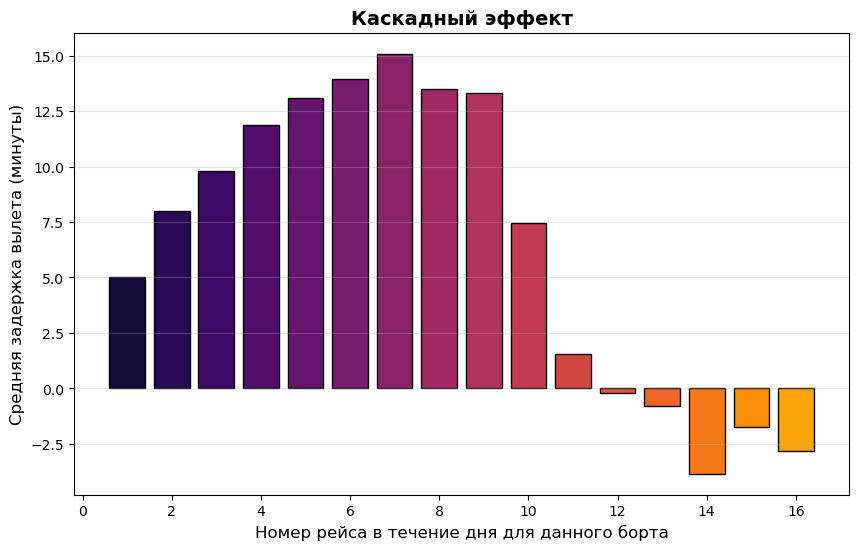

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

flights = pd.read_csv('flights.csv', low_memory = False)

flights_valid = flights[flights['CANCELLED'] == 0].copy()
flights_valid = flights_valid[flights_valid['DEPARTURE_DELAY'].notna()]

flights['HOUR'] = flights['SCHEDULED_DEPARTURE'] // 100

flights_valid['DATE'] = flights_valid['YEAR'].astype(str) + '-' + \
                        flights_valid['MONTH'].astype(str) + '-' + \
                        flights_valid['DAY'].astype(str)

flights_valid = flights_valid.sort_values(['TAIL_NUMBER', 'DATE', 'SCHEDULED_DEPARTURE'])
flights_valid['FLIGHT_OF_DAY'] = flights_valid.groupby(['TAIL_NUMBER', 'DATE']).cumcount() + 1

delay_by_flight_num = flights_valid.groupby('FLIGHT_OF_DAY')['DEPARTURE_DELAY'].mean()

print("\n\nСредняя задержка по порядковому номеру рейса в день:")
print(delay_by_flight_num)

colors = plt.cm.inferno(np.linspace(0.1, 0.8, len(delay_by_flight_num)))

plt.figure(figsize = (10, 6))
plt.bar(delay_by_flight_num.index, delay_by_flight_num.values, color = colors, edgecolor = 'black')
plt.xlabel('Номер рейса в течение дня для данного борта', fontsize = 12)
plt.ylabel('Средняя задержка вылета (минуты)', fontsize = 12)
plt.title('Каскадный эффект', fontsize = 14, fontweight = 'bold')
plt.grid(True, alpha = 0.3, axis = 'y')
plt.show()



Наблюдается накопление задержки: В начале задержка растет, достигает максимума = 15 мин, затем начинается спад
Возможно в середине дня авиакомпании стараются отправлять самолеты раньше расписания, дабы копменсировать задержку
Возможное решение: Увеличить смены сотрудников досмотра и экспедиторов, внедрить какую-то оптимизацию в пиковый период.


Рассмотреть средние задержки и процент задержек авиакомпаний

                              mean_delay  median_delay  count_flights  \
AIRLINE_y                                                               
Spirit Air Lines               15.883101          -1.0         115193   
United Air Lines Inc.          14.333056           1.0         507762   
Frontier Airlines Inc.         13.303352          -2.0          90090   
JetBlue Airways                11.442467          -2.0         262042   
Southwest Airlines Co.         10.517183           0.0        1242403   
American Eagle Airlines Inc.    9.967187          -2.0         278791   
Virgin America                  8.993486          -1.0          61248   
American Airlines Inc.          8.826106          -2.0         712935   
Atlantic Southeast Airlines     8.615598          -3.0         554752   
Skywest Airlines Inc.           7.736083          -3.0         576814   
Delta Air Lines Inc.            7.313300          -1.0         870275   
US Airways Inc.                 6.081000          -

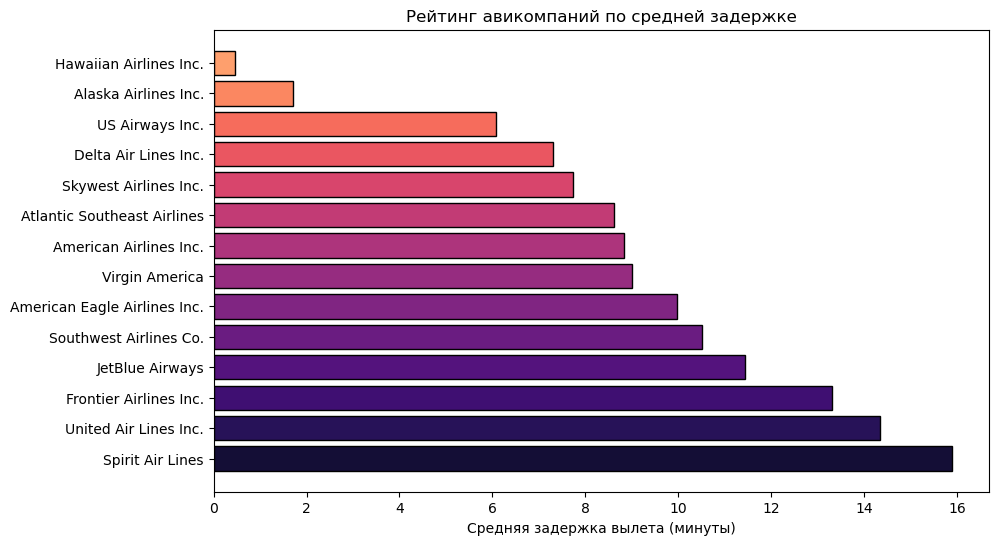

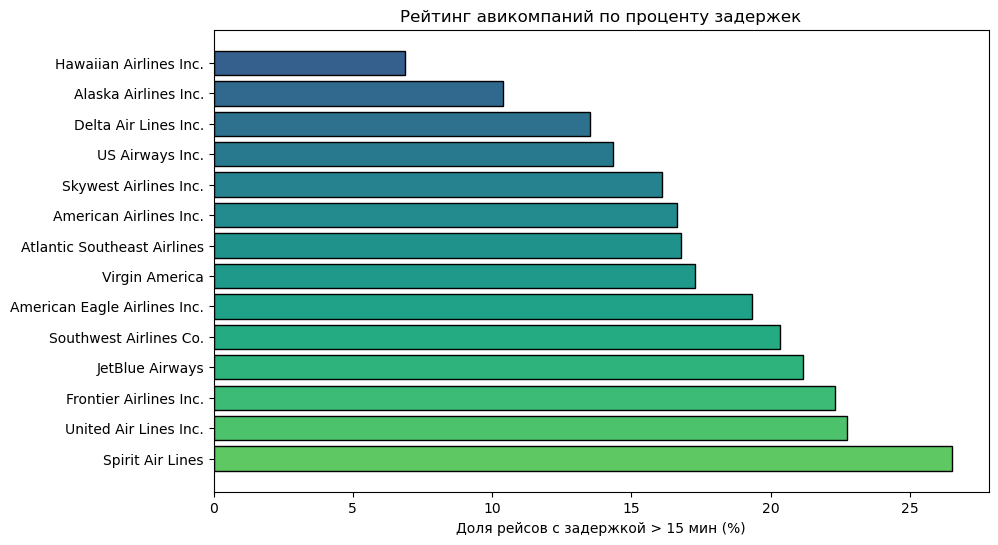

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

flights = pd.read_csv('flights.csv', low_memory = False)
airlines = pd.read_csv('airlines.csv', low_memory = False)

flights = flights.merge(airlines, left_on = 'AIRLINE', right_on = 'IATA_CODE', how = 'left')

flights = flights[flights['CANCELLED'] == 0].copy()
flights = flights.dropna(subset = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])
flights['IS_DELAYED'] = flights['DEPARTURE_DELAY'] > 15

groups = flights.groupby('AIRLINE_y')
mean_delay = groups['DEPARTURE_DELAY'].mean()
median_delay = groups['DEPARTURE_DELAY'].median()
count_flights = groups['FLIGHT_NUMBER'].count()
delay_rate = groups['IS_DELAYED'].mean() * 100 

table = flights.groupby('AIRLINE_y').agg(
    mean_delay = ('DEPARTURE_DELAY', 'mean'),
    median_delay = ('DEPARTURE_DELAY', 'median'),
    count_flights = ('FLIGHT_NUMBER', 'count'),
    delay_rate = ('IS_DELAYED', 'mean')
)

table['delay_rate'] = table['delay_rate'] * 100
table = table.sort_values('mean_delay', ascending = False)

airline_stats = pd.DataFrame({
    'mean_delay': mean_delay,
    'median_delay': median_delay,
    'delay_rate': delay_rate,
    'flight_count': count_flights
})

airline_stats = airline_stats.sort_values('mean_delay', ascending = False)

print(airline_stats)
print("\n")

delayed1 = airline_stats.sort_values('mean_delay', ascending = False)
delayed2 = airline_stats.sort_values('delay_rate', ascending = False)

colors1 = plt.cm.magma(np.linspace(0.1, 0.8, len(delayed1)))
colors2 = plt.cm.viridis(np.linspace(0.75, 0.3, len(delayed2)))

plt.figure(figsize = (10, 6))
plt.barh(delayed1.index, delayed1['mean_delay'], color = colors1, edgecolor = 'black')
plt.xlabel('Средняя задержка вылета (минуты)')
plt.title('Рейтинг авикомпаний по средней задержке')
plt.show()

plt.figure(figsize = (10, 6))
plt.barh(delayed2.index, delayed2['delay_rate'], color = colors2, edgecolor='black')
plt.xlabel('Доля рейсов с задержкой > 15 мин (%)')
plt.title('Рейтинг авикомпаний по проценту задержек')
plt.show()

Авиакомпании с низкой средней задержкой обычно успешно оптимизируют наземные процессы — быстрая посадка, четкая координация с аэропортовыми службами, наличие резервных самолетов. Авиакомпании с высокой задержкой, напротив, имеют конретные недочеты в этих областях
Решение: Инвестировать в обучение персонала, а также покупку дополнительных воздушных судов. Повысить оперативную гибкость 


Проанализировать процент задержанных рейсов в каждый из дней недели

DAY_OF_WEEK
Понедельник    18.836437
Вторник        17.354384
Среда          17.152727
Четверг        18.574846
Пятница        18.146742
Суббота        15.728566
Воскресенье    17.750435
Name: IS_DELAYED, dtype: float64


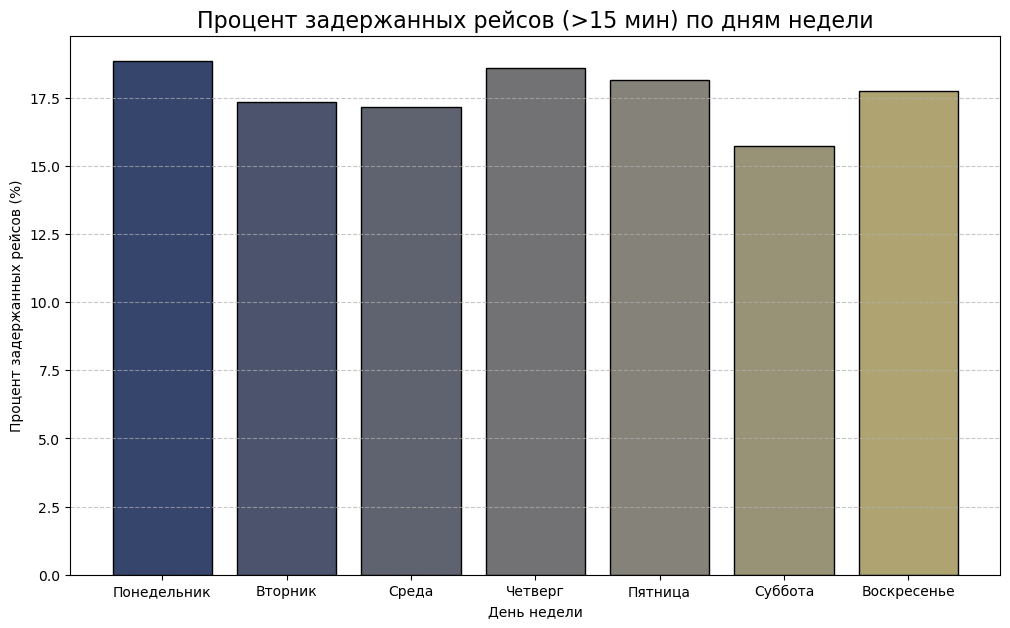

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

flights = pd.read_csv('flights.csv', low_memory = False)

flights = flights[flights['CANCELLED'] == 0].copy()
flights = flights.dropna(subset = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])

flights['IS_DELAYED'] = flights['DEPARTURE_DELAY'] > 15

flights['DATE'] = pd.to_datetime(flights['YEAR'].astype(str) + '-' + \
                        flights['MONTH'].astype(str) + '-' + \
                        flights['DAY'].astype(str))
flights['DAY_OF_WEEK'] = flights['DATE'].dt.dayofweek

delay_rate_by_day = flights.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean() * 100

day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
delay_rate_by_day.index = delay_rate_by_day.index.map(lambda i: day_names[i])

print(delay_rate_by_day)

colors = plt.cm.cividis(np.linspace(0.2, 0.7, len(delay_rate_by_day)))

plt.figure(figsize = (12, 7))
plt.bar(
    delay_rate_by_day.index, 
    delay_rate_by_day.values,
    color = colors,
    edgecolor = 'black'
)

plt.title('Процент задержанных рейсов (>15 мин) по дням недели', fontsize=16)
plt.xlabel('День недели')
plt.ylabel('Процент задержанных рейсов (%)')
plt.grid(axis = 'y', linestyle='--', alpha=0.7)
plt.show()
#не заметил, что в базе изначально есть распределения по дням недели 

Решение: попытаться большинтсво авиарейсов перевести на дни с наименьшим процентом задержанных рейсов 

Рассмотреть среднюю задержку авиарейсов в зависимости от дистанции рейса

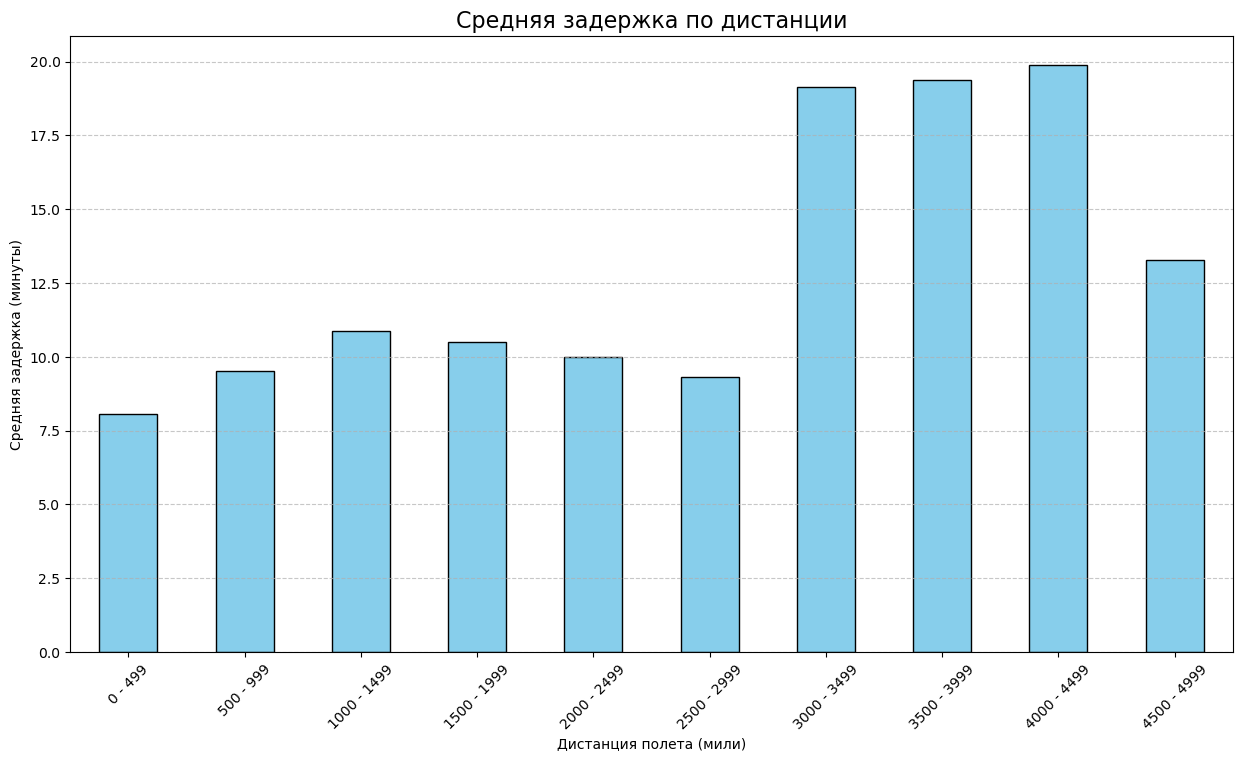

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

flights = pd.read_csv('flights.csv', low_memory = False)

flights = flights[flights['CANCELLED'] == 0].copy()
flights = flights.dropna(subset = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])

max_dist = int(flights['DISTANCE'].max())
bins = range(0, max_dist + 500, 500)
labels = [f'{i} - {i + 499}' for i in bins[:-1]]
flights['DISTANCE_BIN'] = pd.cut(flights['DISTANCE'], bins = bins, labels = labels, right = False)

mean_delay_by_dist = flights.groupby('DISTANCE_BIN', observed = True)['DEPARTURE_DELAY'].mean().dropna()

plt.figure(figsize = (15, 8))
mean_delay_by_dist.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')

plt.title('Средняя задержка по дистанции', fontsize=16)
plt.xlabel('Дистанция полета (мили)')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()


Рейсы с дистанцией 3000+ имеют значительный рост задержки по отношению к другим.
Возможная причина: На больших расстояниях больше требований к подготовке, заправке, проверкам и погрузке багажа

Рассмотреть долю возникновение задержек по причине 'безопасности'

                total  delayed
ORIGIN_AIRPORT                
ABE              2235        0
ABI              2232        3
ABQ             18980       12
ABR               663        3
ABY               867        0
...               ...      ...
WRG               653        3
WYS               208        0
XNA              8987        1
YAK               657        0
YUM              1854        1

[322 rows x 2 columns]
                 total  delayed  delay_rate
ORIGIN_AIRPORT                             
SIT               1333        7    0.525131
ASE               3286       12    0.365186
CLT              99243      286    0.288182
STT               4299       12    0.279135
PHX             145913      341    0.233701
KTN               2291        5    0.218245
SBN               4353        9    0.206754
JFK              91889      180    0.195889
SJT               1551        3    0.193424
SJU              24465       44    0.179849
HPN               7164       12    0.167504
P

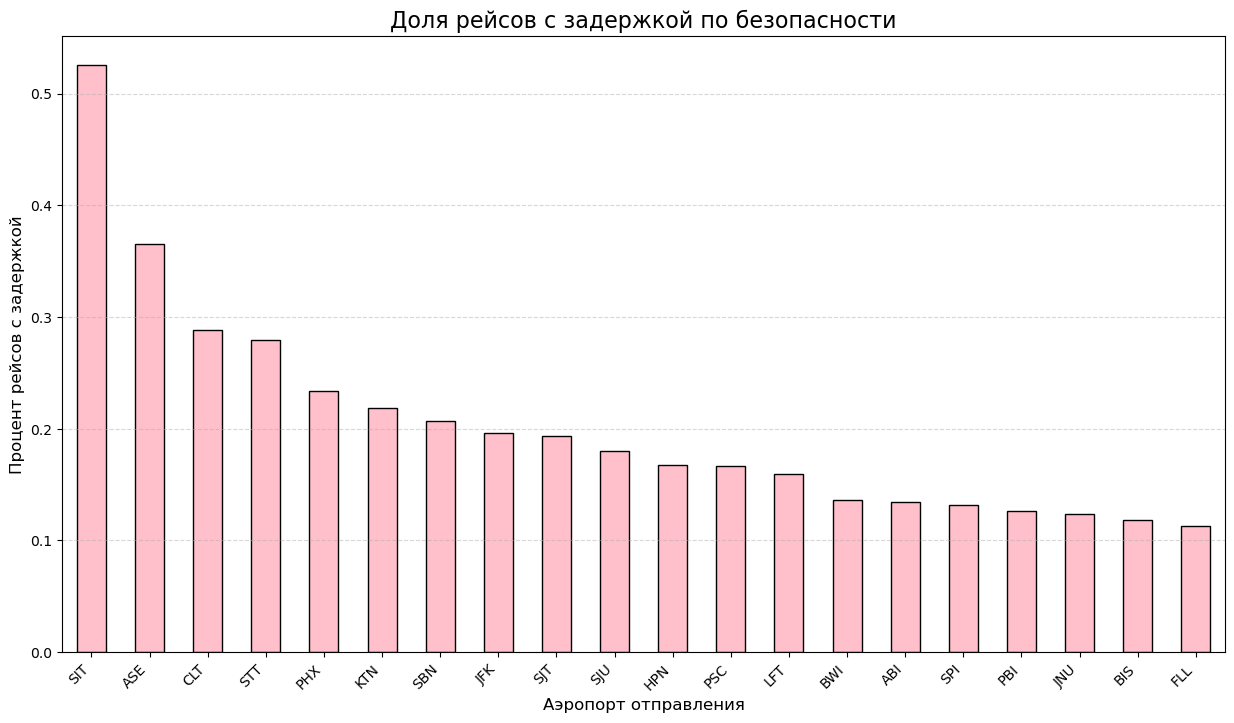

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

flights = pd.read_csv('flights.csv', low_memory = False)

flights = flights[flights['CANCELLED'] == 0].copy()
flights = flights[flights['ORIGIN_AIRPORT'].str.match(r'^[A-Z]{3}$', na=False)]
flights['SECURITY_DELAY'] = flights['SECURITY_DELAY'].fillna(0)


airport_analysis = flights.groupby('ORIGIN_AIRPORT').agg(
    total = ('SECURITY_DELAY', 'count'),
    delayed = ('SECURITY_DELAY', lambda x: (x > 0).sum())
)

print(airport_analysis)


airport_analysis['delay_rate'] = ((airport_analysis['delayed'] / airport_analysis['total']) * 100)

big_airports = airport_analysis[airport_analysis['total'] > 1000]

sorted_by_rate = big_airports.sort_values('delay_rate', ascending = False)

print(sorted_by_rate.head(20))

plt.figure(figsize = (15, 8))

sorted_by_rate.head(20)['delay_rate'].plot(kind = 'bar', color = 'pink', edgecolor = 'black')

plt.title('Доля рейсов с задержкой по безопасности', fontsize = 16)
plt.xlabel('Аэропорт отправления', fontsize = 12)
plt.ylabel('Процент рейсов с задержкой', fontsize=12)

plt.xticks(rotation=45, ha = 'right')

plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)
plt.show()

Усилить безопасность в аэропортах, имеющих относительно высокий процент задержек, по отношению к другим аэропортам